### Gibbs Sampling

Gibbs sampler for a bivariate Gaussian distribution (Gibbs-Gauss function), involves defining the conditional distributions and iteratively sampling from them to generate samples from the joint distribution.

**To implement the Gibbs-Gauss sampler**
- Define the parameters for the bivariate Gaussian distribution (means, standard deviations, and correlation).
- Gibbs sampling function, that takes the number of samples and a burn-in period as input.
- Inside the sampling loop, for each iteration, sample x1 given x2 (which is a conditional Gaussian) and then sample x2 given the newly sampled x1 (also a conditional Gaussian).
- Store the samples after the burn-in period.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gibbs_gauss(mu1, mu2, sigma1, sigma2, rho, num_samples, burn_in):
    '''
    Implements Gibbs sampling for a bivariate Gaussian distribution.

    Args:
        mu1 (float), mu2 (float): Mean of X1, X2
        sigma1 (float), sigma2 (float): Std of  X1, X2
        rho (float): Correlation coefficient between X1 and X2.
        num_samples (int): Total number of samples to generate.
        burn_in (int): Number of initial samples to discard.

    Returns:
        numpy.ndarray: An array of shape (num_samples - burn_in, 2) containing the sampled pairs (x1, x2).
    '''
    samples = np.zeros((num_samples, 2))

    # Initialize with arbitrary values
    x1 = mu1
    x2 = mu2

    for i in range(num_samples):
        # Sample x1 given x2, conditional mean of X1 given X2=x2
        cond_mu1 = mu1 + rho * (sigma1 / sigma2) * (x2 - mu2)
        # Conditional variance of X1 given X2=x2
        cond_sigma1 = sigma1 * np.sqrt(1 - rho**2)
        x1 = np.random.normal(loc=cond_mu1, scale=cond_sigma1)

        # Sample x2 given x1 (new x1), Conditional mean of X2 given X1=x1
        cond_mu2 = mu2 + rho * (sigma2 / sigma1) * (x1 - mu1)
        # Conditional variance of X2 given X1=x1
        cond_sigma2 = sigma2 * np.sqrt(1 - rho**2)
        x2 = np.random.normal(loc=cond_mu2, scale=cond_sigma2)

        samples[i] = [x1, x2]

    return samples[burn_in:]

# Define parameters for the bivariate Gaussian distribution
mu1_gg, mu2_gg = 0, 0
sigma1_gg, sigma2_gg = 1, 1
rho_gg = 0.8  # Correlation coefficient

# Sampling parameters
num_samples_gg = 50000
burn_in_gg = 1000

# Run the Gibbs sampler
gibbs_samples = gibbs_gauss(mu1_gg, mu2_gg, sigma1_gg, sigma2_gg, rho_gg, num_samples_gg, burn_in_gg)

print(f"Generated {len(gibbs_samples)} samples from the bivariate Gaussian distribution. \n"
f"Mean of X1 samples: {np.mean(gibbs_samples[:, 0]):.3f}, "
f"Mean of X2 samples: {np.mean(gibbs_samples[:, 1]):.3f} \n"
f"Std Dev of X1 samples: {np.std(gibbs_samples[:, 0]):.3f}, "
f"Std Dev of X2 samples: {np.std(gibbs_samples[:, 1]):.3f} \n"
f"Correlation of samples: {np.corrcoef(gibbs_samples[:, 0], gibbs_samples[:, 1])[0, 1]:.3f}")

Generated 49000 samples from the bivariate Gaussian distribution. 
Mean of X1 samples: -0.006, Mean of X2 samples: -0.008 
Std Dev of X1 samples: 0.992, Std Dev of X2 samples: 0.990 
Correlation of samples: 0.797


Scatter plot of the generated samples to visually inspect if the samples resemble the expected bivariate Gaussian distribution, particularly observing the elliptical shape dictated by the correlation.


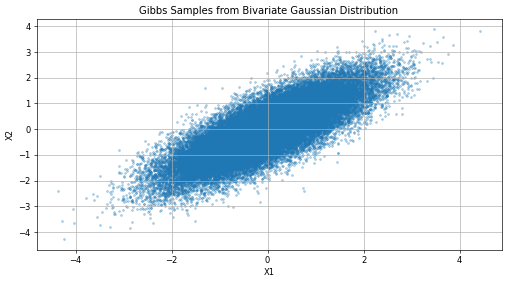

In [ ]:
plt.figure(figsize=(10, 5), dpi=60)
plt.scatter(gibbs_samples[:, 0], gibbs_samples[:, 1], alpha=0.3, s=5)
plt.title('Gibbs Samples from Bivariate Gaussian Distribution')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()